In [8]:
# Cell 1: Imports and Setup
import sys
from pathlib import Path

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from dataset import VehicleDataset, get_transforms
from model import VehicleCNN
from trainer import Trainer, compute_class_weights

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
DATA_DIR = PROJECT_ROOT / "data" / "splits"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Using device: cuda
Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
Data directory: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\splits


In [9]:
# Cell 2: Hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_CLASSES = 12
DROPOUT = 0.5

print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Image Size: {IMG_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")

Batch Size: 32
Epochs: 100
Learning Rate: 0.001
Image Size: 224
Number of Classes: 12


In [10]:
# Cell 3: Load Datasets
train_transform = get_transforms('train', img_size=IMG_SIZE)
val_transform = get_transforms('val', img_size=IMG_SIZE)

train_dataset = VehicleDataset(TRAIN_DIR, transform=train_transform)
val_dataset = VehicleDataset(VAL_DIR, transform=val_transform)

print("\nClass distribution (train):")
train_counts = train_dataset.get_class_counts()
for class_name, count in sorted(train_counts.items()):
    print(f"  {class_name}: {count}")

Found 1418 images in 12 classes
Found 322 images in 12 classes

Class distribution (train):
  class_01_motorcycle: 203
  class_02_passenger_car: 590
  class_03_four_tire_single_unit: 49
  class_04_bus: 182
  class_05_two_axle_six_tire_single_unit: 60
  class_06_three_axle_single_unit: 88
  class_07_four_or_more_axle_single_unit: 28
  class_08_four_or_less_axle_single_trailer: 44
  class_09_five_axle_tractor_semitrailer: 56
  class_10_six_or_more_axle_single_trailer: 41
  class_11_five_or_less_axle_multi_trailer: 28
  class_13_seven_or_more_axle_multi_trailer: 49


In [11]:
# Cell 4: Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows to avoid multiprocessing issues
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 45
Val batches: 11


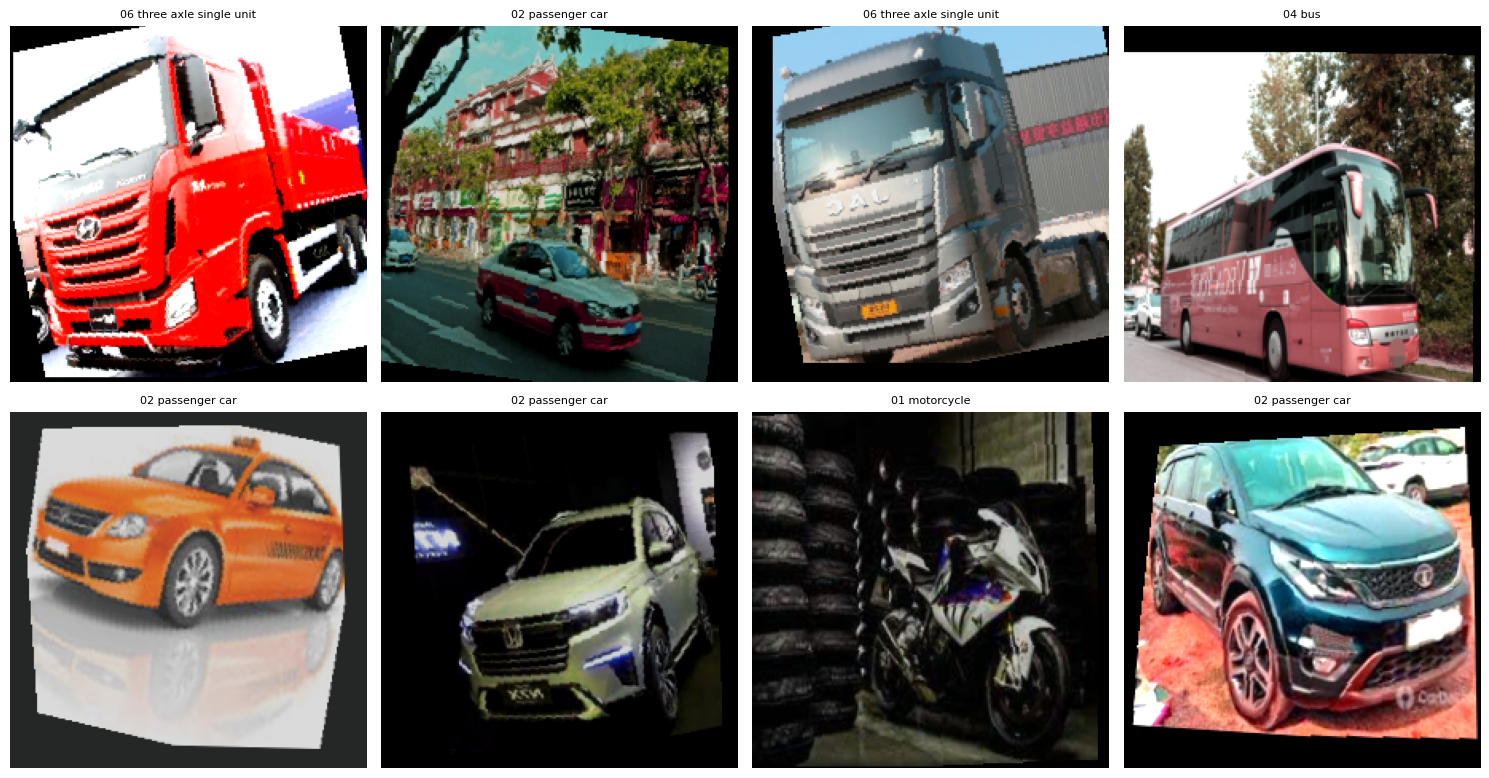

In [12]:
# Cell 5: Visualize Sample Batch
def denormalize(tensor):
    """Denormalize image tensor for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get one batch
images, labels = next(iter(train_loader))

# Plot first 8 images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        class_name = train_dataset.idx_to_class[labels[i].item()]
        ax.set_title(class_name.replace('class_', '').replace('_', ' '), fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "sample_batch.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 6: Initialize Model
model = VehicleCNN(num_classes=NUM_CLASSES, dropout=DROPOUT)
model = model.to(device)

print(f"Model created with {model.get_num_params():,} parameters")
print("\nModel architecture:")
print(model)

Model created with 1,737,100 parameters

Model architecture:
VehicleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [14]:
# Cell 7: Loss Function with Class Weights (for imbalance)
class_weights = compute_class_weights(train_dataset)
print("Class weights:")
for i, weight in enumerate(class_weights):
    print(f"  {train_dataset.idx_to_class[i]}: {weight:.3f}")

class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights:
  class_01_motorcycle: 0.272
  class_02_passenger_car: 0.094
  class_03_four_tire_single_unit: 1.127
  class_04_bus: 0.303
  class_05_two_axle_six_tire_single_unit: 0.920
  class_06_three_axle_single_unit: 0.627
  class_07_four_or_more_axle_single_unit: 1.972
  class_08_four_or_less_axle_single_trailer: 1.255
  class_09_five_axle_tractor_semitrailer: 0.986
  class_10_six_or_more_axle_single_trailer: 1.347
  class_11_five_or_less_axle_multi_trailer: 1.972
  class_13_seven_or_more_axle_multi_trailer: 1.127


In [15]:
# Cell 8: Optimizer and Scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)")

Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)


In [16]:
# Cell 9: Create Trainer and Start Training
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    save_dir=OUTPUT_DIR / "checkpoints"
)

# Train the model
history = trainer.train(num_epochs=NUM_EPOCHS, scheduler=scheduler)

Starting training for 100 epochs...
Device: cuda
Train samples: 1418
Val samples: 322
------------------------------------------------------------


c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/100] Train Loss: 2.6042 | Train Acc: 0.1220 | Val Loss: 2.4435 | Val Acc: 0.0621
  → Best model saved! (Val Acc: 0.0621)
Epoch [2/100] Train Loss: 2.5470 | Train Acc: 0.1150 | Val Loss: 2.4309 | Val Acc: 0.1242
  → Best model saved! (Val Acc: 0.1242)
Epoch [3/100] Train Loss: 2.4586 | Train Acc: 0.1678 | Val Loss: 2.3851 | Val Acc: 0.1522
  → Best model saved! (Val Acc: 0.1522)
Epoch [4/100] Train Loss: 2.4343 | Train Acc: 0.1700 | Val Loss: 2.3215 | Val Acc: 0.1335
Epoch [5/100] Train Loss: 2.3833 | Train Acc: 0.1784 | Val Loss: 2.3292 | Val Acc: 0.1398
Epoch [6/100] Train Loss: 2.3932 | Train Acc: 0.1643 | Val Loss: 2.3707 | Val Acc: 0.1429
Epoch [7/100] Train Loss: 2.3535 | Train Acc: 0.1784 | Val Loss: 2.1849 | Val Acc: 0.1801
  → Best model saved! (Val Acc: 0.1801)
Epoch [8/100] Train Loss: 2.3030 | Train Acc: 0.2031 | Val Loss: 2.3407 | Val Acc: 0.1460
Epoch [9/100] Train Loss: 2.2615 | Train Acc: 0.2285 | Val Loss: 2.4685 | Val Acc: 0.1149
Epoch [10/100] Train Loss: 2.2

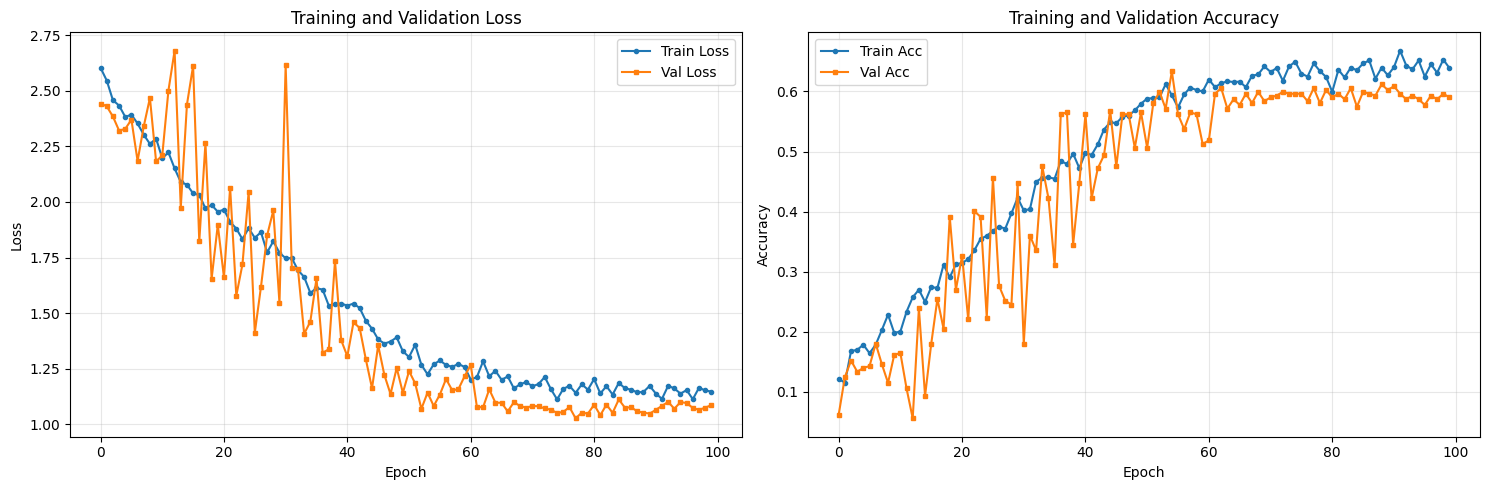

Best validation accuracy: 0.6335


In [17]:
# Cell 10: Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax1.plot(history['val_loss'], label='Val Loss', marker='s', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o', markersize=3)
ax2.plot(history['val_acc'], label='Val Acc', marker='s', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {trainer.best_val_acc:.4f}")

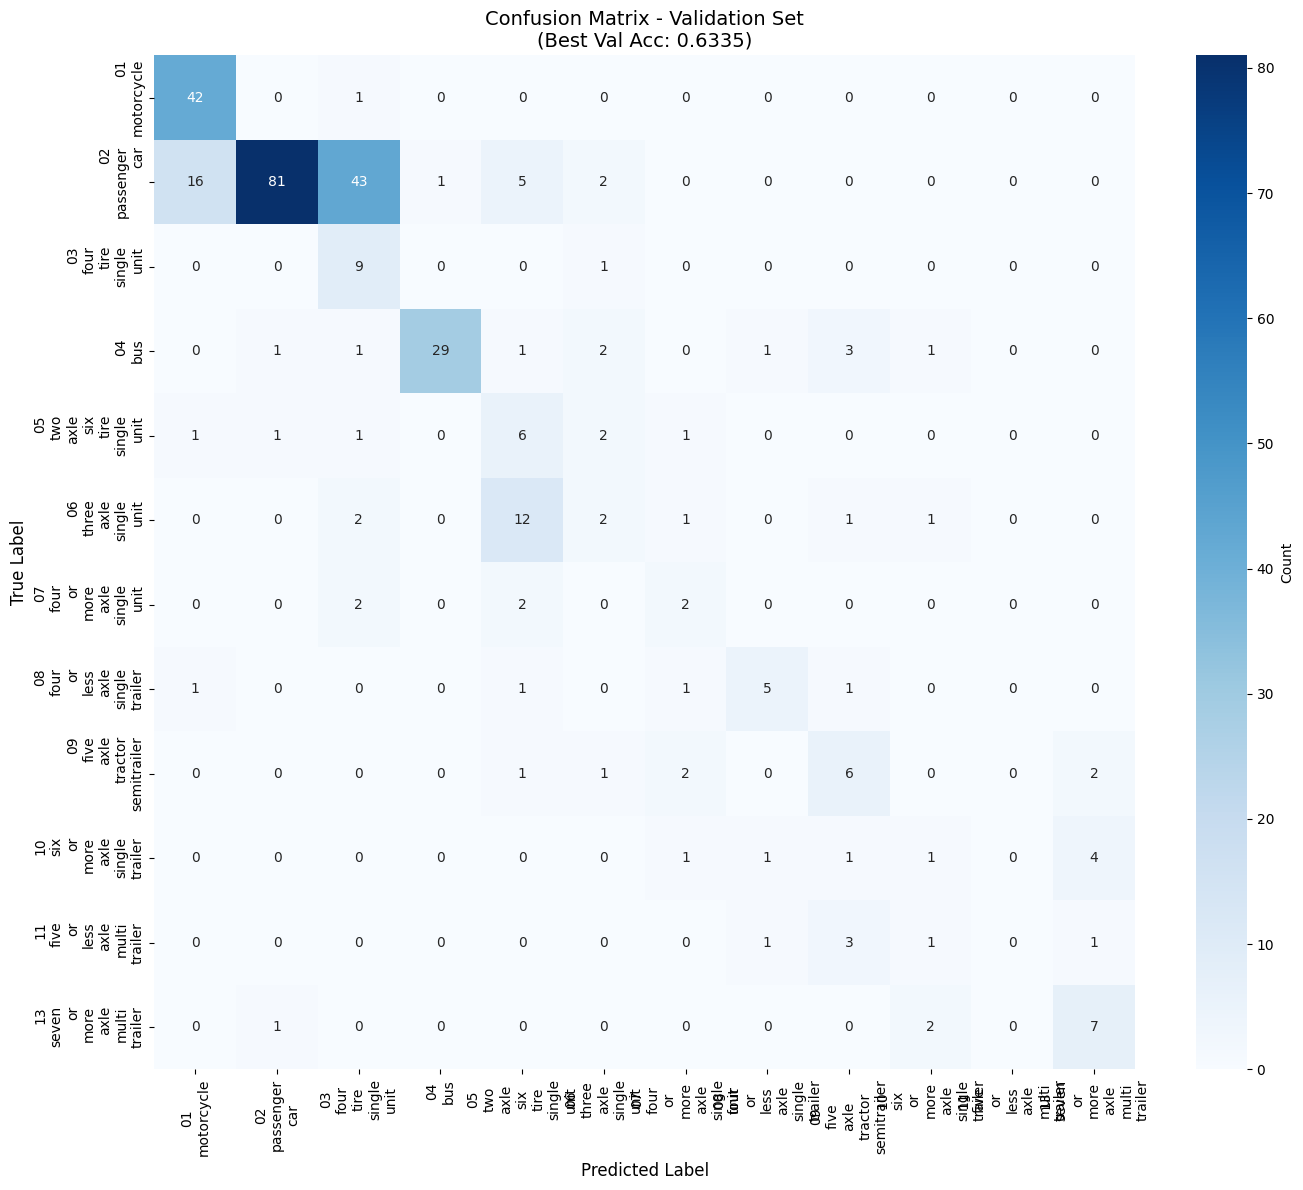


Classification Report (Validation Set):
                                     precision    recall  f1-score   support

                      01 motorcycle     0.7000    0.9767    0.8155        43
                   02 passenger car     0.9643    0.5473    0.6983       148
           03 four tire single unit     0.1525    0.9000    0.2609        10
                             04 bus     0.9667    0.7436    0.8406        39
   05 two axle six tire single unit     0.2143    0.5000    0.3000        12
          06 three axle single unit     0.2000    0.1053    0.1379        19
   07 four or more axle single unit     0.2500    0.3333    0.2857         6
08 four or less axle single trailer     0.6250    0.5556    0.5882         9
   09 five axle tractor semitrailer     0.4000    0.5000    0.4444        12
 10 six or more axle single trailer     0.1667    0.1250    0.1429         8
 11 five or less axle multi trailer     0.0000    0.0000    0.0000         6
13 seven or more axle multi traile

c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [18]:
# Cell 11: Generate Confusion Matrix on Validation Set
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, data_loader, device):
    """Get all predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions
val_preds, val_labels = get_predictions(model, val_loader, device)

# Compute confusion matrix
cm = confusion_matrix(val_labels, val_preds)

# Plot confusion matrix
plt.figure(figsize=(14, 12))
class_names = [name.replace('class_', '').replace('_', '\n') for name in val_dataset.idx_to_class.values()]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Validation Set\n(Best Val Acc: {trainer.best_val_acc:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "confusion_matrix_val.png", dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("\nClassification Report (Validation Set):")
print("="*70)
target_names = [name.replace('class_', '').replace('_', ' ') for name in val_dataset.idx_to_class.values()]
print(classification_report(val_labels, val_preds, target_names=target_names, digits=4))

FINAL EVALUATION ON TEST SET
Found 334 images in 12 classes
Test samples: 334

Test Accuracy: 0.5689


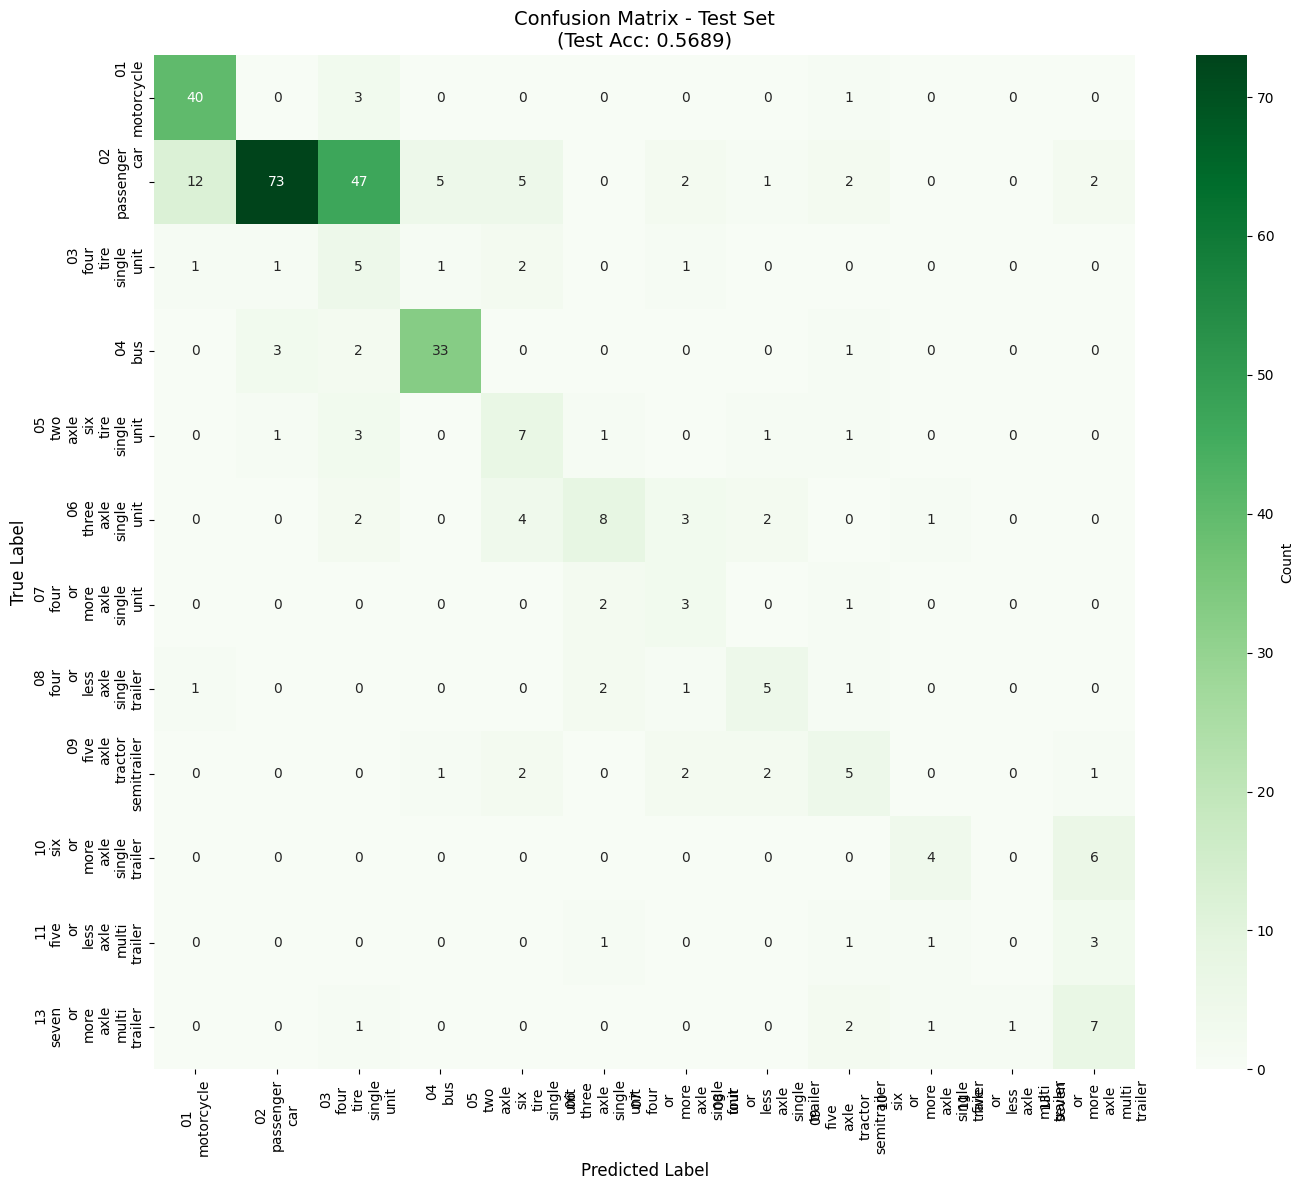


Classification Report (Test Set):
                                     precision    recall  f1-score   support

                      01 motorcycle     0.7407    0.9091    0.8163        44
                   02 passenger car     0.9359    0.4899    0.6432       149
           03 four tire single unit     0.0794    0.4545    0.1351        11
                             04 bus     0.8250    0.8462    0.8354        39
   05 two axle six tire single unit     0.3500    0.5000    0.4118        14
          06 three axle single unit     0.5714    0.4000    0.4706        20
   07 four or more axle single unit     0.2500    0.5000    0.3333         6
08 four or less axle single trailer     0.4545    0.5000    0.4762        10
   09 five axle tractor semitrailer     0.3333    0.3846    0.3571        13
 10 six or more axle single trailer     0.5714    0.4000    0.4706        10
 11 five or less axle multi trailer     0.0000    0.0000    0.0000         6
13 seven or more axle multi trailer     

: 

In [ ]:
# Cell 12: Evaluate on Test Set
print("="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

# Load test dataset
test_transform = get_transforms('test', img_size=IMG_SIZE)
test_dataset = VehicleDataset(TEST_DIR, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")

# Get predictions on test set
test_preds, test_labels = get_predictions(model, test_loader, device)

# Compute test accuracy
test_accuracy = (test_preds == test_labels).mean()
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Confusion matrix for test set
cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Test Set\n(Test Acc: {test_accuracy:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "confusion_matrix_test.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification report for test set
print("\nClassification Report (Test Set):")
print("="*70)
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))